## GENDER BIAS ANALYSIS ACROSS MULTILINGUAL WORD2VEC MODELS


#### Imports and Cleaning Data

In [19]:
# imports
import numpy as np
from gensim.models import Word2Vec
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [20]:
# load models and print number of words in each embedding
MODEL_PATHS_EMBEDDINGS= {
    "english":  "../data/embeddings/english_philosophy.model",
    "german":   "../data/embeddings/german_philosophy.model",
    "arabic":   "../data/embeddings/arabic_philosophy.model",
    "russian":  "../data/embeddings/russian_philosophy.model",
    "spanish":  "../data/embeddings/spanish_philosophy.model",
}

models = {}
for lang, path in MODEL_PATHS_EMBEDDINGS.items():
    try:
        models[lang] = Word2Vec.load(path).wv
        print(f"{lang}: {len(models[lang])} words")
    except Exception as e:
        print(f"{lang} did not work: {e}")

english: 1227 words
german: 2121 words
arabic: 1247 words
russian: 2026 words
spanish: 2827 words


In [21]:
# eda for overall representation of well-known male vs female philosophers
FEMALE_PHILOSOPHERS = ["hypatia", "arendt", "wollstonecraft", "beauvoir", 
                       "midgley", "anscombe", "murdoch", "nussbaum", 
                       "kristeva", "irigaray"]
MALE_PHILOSOPHERS = ["aristotle", "plato", "kant", "hegel", "socrates",
                     "descartes", "nietzsche", "locke", "hume", "marx"]

print("Philosopher representation by language:")
for lang, wv in models.items():
    found_f = [n for n in FEMALE_PHILOSOPHERS if n in wv]
    found_m = [n for n in MALE_PHILOSOPHERS if n in wv]
    print(f"\n{lang}")
    print(f"male: {len(found_m)}/10 {found_m}")
    print(f"female: {len(found_f)}/10 {found_f}")

# no women philosophers in the russian embedding indicates gender bias trend

Philosopher representation by language:

english
male: 4/10 ['aristotle', 'plato', 'kant', 'socrates']
female: 2/10 ['wollstonecraft', 'beauvoir']

german
male: 10/10 ['aristotle', 'plato', 'kant', 'hegel', 'socrates', 'descartes', 'nietzsche', 'locke', 'hume', 'marx']
female: 1/10 ['arendt']

arabic
male: 10/10 ['aristotle', 'plato', 'kant', 'hegel', 'socrates', 'descartes', 'nietzsche', 'locke', 'hume', 'marx']
female: 3/10 ['arendt', 'beauvoir', 'anscombe']

russian
male: 10/10 ['aristotle', 'plato', 'kant', 'hegel', 'socrates', 'descartes', 'nietzsche', 'locke', 'hume', 'marx']
female: 0/10 []

spanish
male: 10/10 ['aristotle', 'plato', 'kant', 'hegel', 'socrates', 'descartes', 'nietzsche', 'locke', 'hume', 'marx']
female: 6/10 ['hypatia', 'arendt', 'wollstonecraft', 'beauvoir', 'midgley', 'kristeva']


#### Gender Direction Bias Analysis

In [22]:
# gender bias -- anchor words are male, female 
GENDER_PAIRS = [
    ("man",    "woman"),
    ("he",     "she"),
    ("his",    "her"),
    ("male",   "female"),
    ("boy",    "girl"),
    ("father", "mother"),
    ("son",    "daughter"),
    ("king",   "queen"),
    ("brother","sister"),
]

def get_gender_direction(wv):
    """Compute gender direction as mean(male anchors) - mean(female anchors)."""
    male_vecs, female_vecs = [], []
    for m, f in GENDER_PAIRS:
        if m in wv and f in wv:
            male_vecs.append(wv[m])
            female_vecs.append(wv[f])
    if not male_vecs:
        return None
    direction = np.mean(male_vecs, axis=0) - np.mean(female_vecs, axis=0)
    return direction / np.linalg.norm(direction)

def gender_score(word, wv, gender_dir):
    """
    Cosine similarity of word's embedding with gender direction.
    Positive = more male-associated, negative = more female-associated.
    """
    if word not in wv or gender_dir is None:
        return None
    v = wv[word]
    v = v / np.linalg.norm(v)
    return float(np.dot(v, gender_dir))

In [23]:
# define test word sets
TEST_WORDS = {
    "professions":  ["doctor", "nurse", "engineer", "teacher", "scientist",
                     "programmer", "artist", "lawyer", "philosopher",
                     "professor", "researcher", "manager", "secretary",
                     "player", "coach", "referee", "drag queen", "activist", 
                     "educator", "principal"],
    "traits":       ["intelligent", "creative", "emotional", "logical",
                     "strong", "gentle", "aggressive", "nurturing",
                     "rational", "irrational", "ambitious", "submissive",
                     "fast", "agile", "adaptable", "successful",
                     "accomplished"],
    "authority":    ["leader", "authority", "president", "boss",
                     "expert", "master", "subordinate", "captain", "best"],
    "philosophy":   ["logic", "reason", "ethics", "wisdom", "knowledge",
                     "truth", "beauty", "virtue", "justice", "mind", "kant"],
}

In [24]:
# score across models
def score_all(models, test_words):
    records = []
    for lang, wv in models.items():
        gdir = get_gender_direction(wv)
        if gdir is None:
            print(f"Warning: no gender anchor words found in {lang} model")
            continue
        for category, words in test_words.items():
            for word in words:
                score = gender_score(word, wv, gdir)
                if score is not None:
                    records.append({
                        "language": lang,
                        "category": category,
                        "word":     word,
                        "score":    score,
                    })
    return pd.DataFrame(records)

df = score_all(models, TEST_WORDS)
print(df)
print(f"\nTotal scored: {len(df)} word-language pairs")


   language     category         word     score
0   english  professions       doctor  0.008459
1   english  professions    scientist -0.143644
2   english  professions  philosopher  0.063471
3   english       traits      logical -0.027670
4   english       traits       strong -0.074712
..      ...          ...          ...       ...
79  spanish   philosophy       beauty -0.005407
80  spanish   philosophy       virtue  0.084191
81  spanish   philosophy      justice  0.130290
82  spanish   philosophy         mind -0.124834
83  spanish   philosophy         kant -0.053762

[84 rows x 4 columns]

Total scored: 84 word-language pairs


In [25]:
# summary: avg bias per language × category
pivot = df.groupby(["language","category"])["score"].mean().unstack()
print("\nMean gender score by language & category")
print("positive = male-leaning, negative = female-leaning\n")
print(pivot.round(3))


Mean gender score by language & category
positive = male-leaning, negative = female-leaning

category  authority  philosophy  professions  traits
language                                            
arabic       -0.063      -0.024        0.073  -0.002
english       0.070       0.038       -0.024   0.010
german       -0.076       0.083        0.013  -0.008
spanish      -0.054       0.024        0.055   0.020


#### WEAT: Word Embedding Association Test

In [26]:
# WEAT measures association -- comparing male vs female associations for each of the language embeddings

WEAT_TARGETS = {
    "career": ["career", "professional", "office", "business",
               "salary", "management", "corporation"],
    "family":  ["home", "family", "children", "marriage",
                "domestic", "wedding", "cook"],
}

WEAT_ATTRS = {
    "male":   ["man", "male", "he", "his", "him", "boy", "brother"],
    "female": ["woman", "female", "she", "her", "hers", "girl", "sister"],
}

def mean_cos_sim(word, attr_words, wv):
    """Mean cosine similarity between word and a set of attribute words."""
    sims = []
    for aw in attr_words:
        if word in wv and aw in wv:
            sims.append(wv.similarity(word, aw))
    return np.mean(sims) if sims else None

def weat_score(wv, targets_a, targets_b, attrs_x, attrs_y):
    """
    WEAT effect size (Cohen's d style).
    Positive = targets_a more associated with attrs_x than targets_b.
    """
    def assoc(word):
        sim_x = mean_cos_sim(word, attrs_x, wv)
        sim_y = mean_cos_sim(word, attrs_y, wv)
        if sim_x is None or sim_y is None:
            return None
        return sim_x - sim_y

    scores_a = [s for w in targets_a if (s := assoc(w)) is not None]
    scores_b = [s for w in targets_b if (s := assoc(w)) is not None]
    if not scores_a or not scores_b:
        return None, None
    all_scores = scores_a + scores_b
    effect = (np.mean(scores_a) - np.mean(scores_b)) / np.std(all_scores)
    
    # One-sided permutation p-value (approximate)
    observed = np.mean(scores_a) - np.mean(scores_b)
    combined = all_scores.copy()
    n_a = len(scores_a)
    count = 0
    N_PERM = 5000
    rng = np.random.default_rng(42)
    for _ in range(N_PERM):
        rng.shuffle(combined)
        diff = np.mean(combined[:n_a]) - np.mean(combined[n_a:])
        if diff >= observed:
            count += 1
    p = count / N_PERM
    return effect, p

print("\nWEAT: career vs. family × male vs. female")
print(f"  Effect > 0 means 'career' words lean more male\n")
for lang, wv in models.items():
    eff, p = weat_score(
        wv,
        WEAT_TARGETS["career"], WEAT_TARGETS["family"],
        WEAT_ATTRS["male"],     WEAT_ATTRS["female"],
    )
    if eff is not None:
        sig = "**" if p < 0.05 else ""
        print(f"{lang} effect={eff:+.3f}  p={p:.3f} {sig}")
    else:
        print(f"{lang} insufficient vocab")


WEAT: career vs. family × male vs. female
  Effect > 0 means 'career' words lean more male

english effect=+1.421  p=0.336 
german insufficient vocab
arabic effect=-2.073  p=1.000 
russian insufficient vocab
spanish effect=+2.000  p=0.499 


#### Neighbor Analysis of Similar Words

In [27]:
# find 10 closest/most similar words
def neighbor_audit(word, models, topn=10):
    print(f"\nNearest neighbors of '{word}'")
    for lang, wv in models.items():
        if word not in wv:
            print(f"  {lang:10s}: (word not in vocab)")
            continue
        neighbors = wv.most_similar(word, topn=topn)
        neighbor_str = ", ".join(f"{w}({s:.2f})" for w, s in neighbors)
        print(f"  {lang:10s}: {neighbor_str}")

In [37]:
neighbor_audit("scientist", models)
neighbor_audit("strong", models)
neighbor_audit("professor", models)
neighbor_audit("kant", models)


Nearest neighbors of 'scientist'
  english   : content(0.29), midwife(0.26), require(0.24), necessary(0.23), 527(0.22), former(0.22), difficult(0.22), discipline(0.22), newton(0.22), 3rd(0.21)
  german    : (word not in vocab)
  arabic    : literature(0.27), nature.(0.26), refers(0.25), after(0.24), well(0.24), cosmology(0.24), set(0.21), biomedical(0.21), arise(0.21), international(0.21)
  russian   : (word not in vocab)
  spanish   : repair(0.30), being(0.30), contrast(0.29), andreas(0.29), deductivism(0.29), american(0.29), there(0.28), people(0.27), 6th(0.27), let(0.27)

Nearest neighbors of 'strong'
  english   : overcome(0.25), introduce(0.25), well(0.23), result(0.23), 427(0.23), ideal(0.22), exclusive(0.22), thought(0.22), prominent(0.21), innovation(0.21)
  german    : thinker(0.28), whether(0.28), andattributed(0.27), ​​through(0.26), preserve(0.25), immanuel(0.24), view(0.24), lead(0.24), salvation(0.24), identity(0.23)
  arabic    : period(0.28), older(0.27), political(0.2

## Kant Analysis

In [42]:
kant = df[df['word'] == 'kant']
kant

,language,category,word,score
17,english,philosophy,kant,-0.014787
37,german,philosophy,kant,0.179108
59,arabic,philosophy,kant,0.107108
83,spanish,philosophy,kant,-0.053762


<BarContainer object of 4 artists>

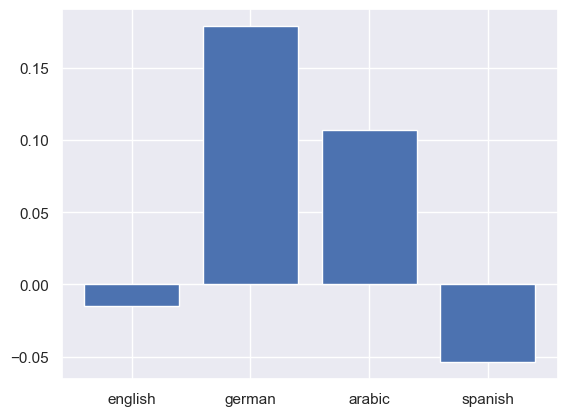

In [45]:
plt.bar(kant['language'], kant['score'])

### Plotting Bias Analysis

In [29]:
# scatter plot of bias scores
def plot_bias_scores(df, category, figsize=(10, 6)):
    sub = df[df["category"] == category].copy()
    
    # pivot so rows=word, cols=language
    pivot = sub.pivot(index="word", columns="language", values="score")
    pivot = pivot.dropna(how="all").sort_values(
        by=pivot.columns[0], ascending=False
    )

    _, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(pivot))
    width = 0.8 / len(pivot.columns)

    for i, lang in enumerate(pivot.columns):
        offset = (i - len(pivot.columns) / 2 + 0.5) * width
        ax.bar(x + offset, pivot[lang].fillna(0), width, label=lang)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right")
    ax.set_title(f"Gender bias: {category} words across languages")
    ax.legend()
    plt.tight_layout()
    plt.show()

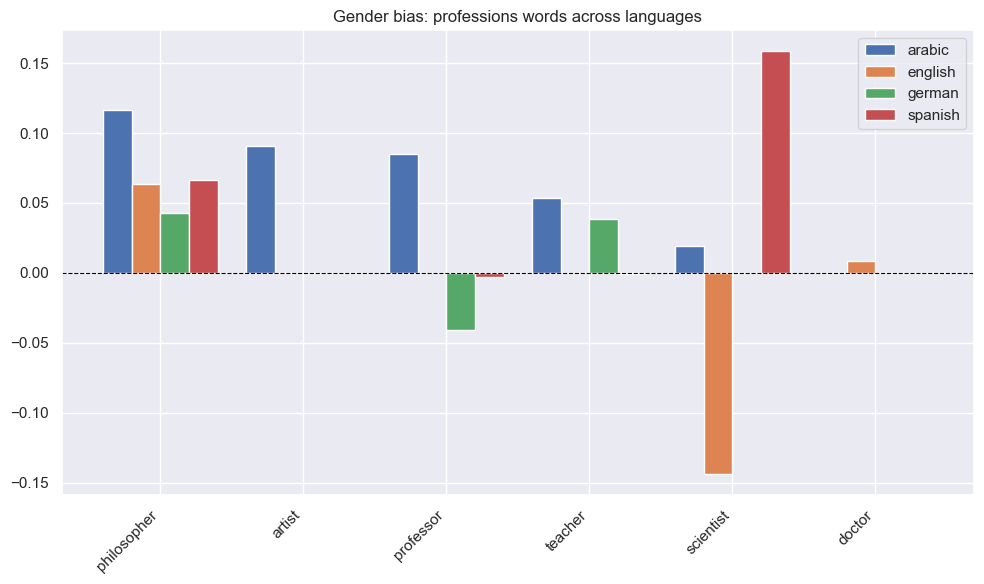

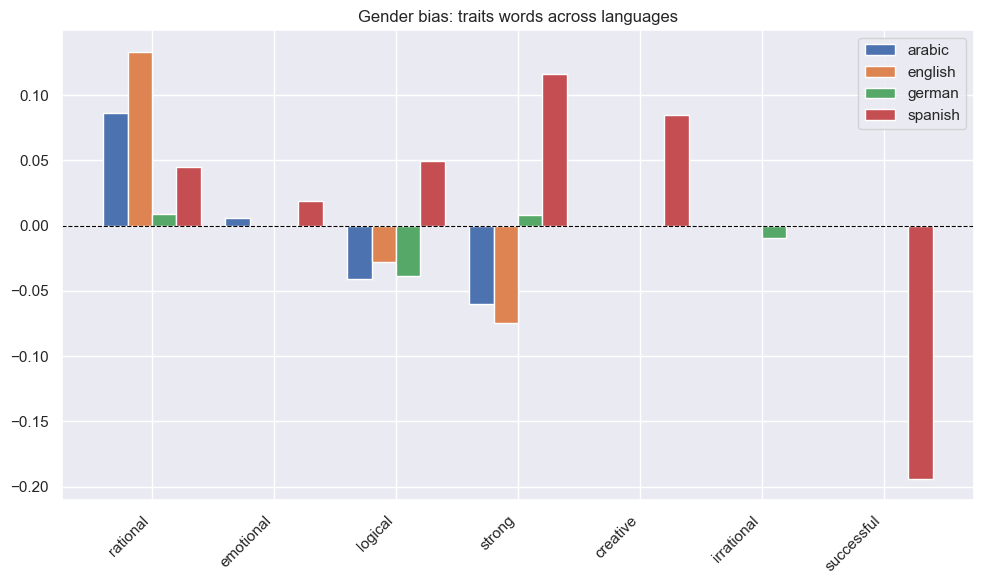

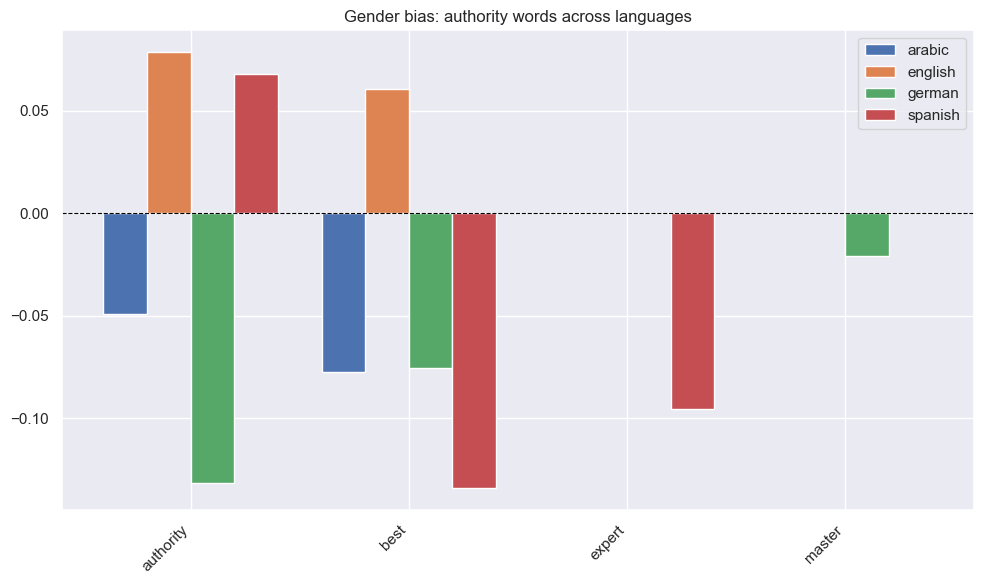

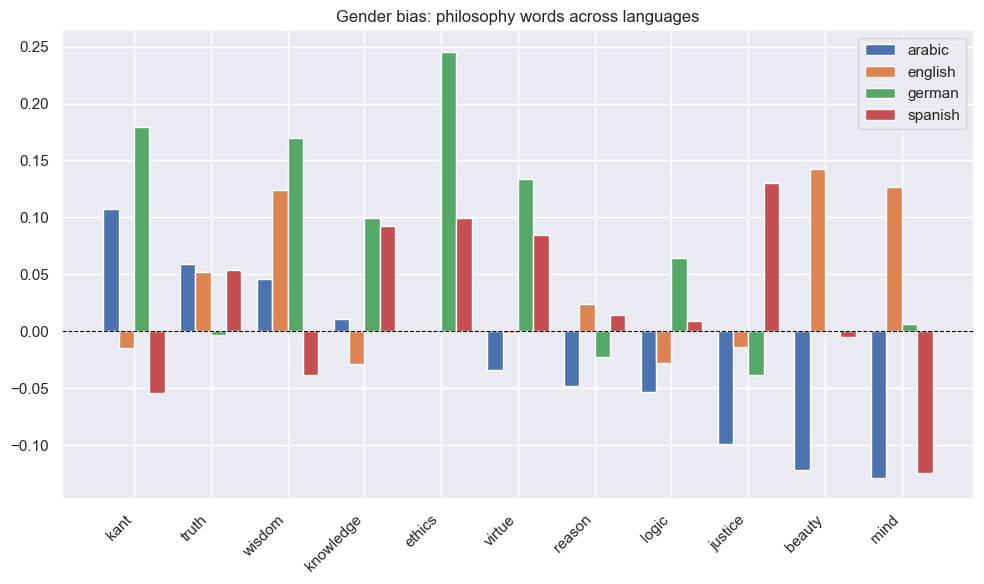

In [30]:
for cat in TEST_WORDS:
    plot_bias_scores(df, cat)

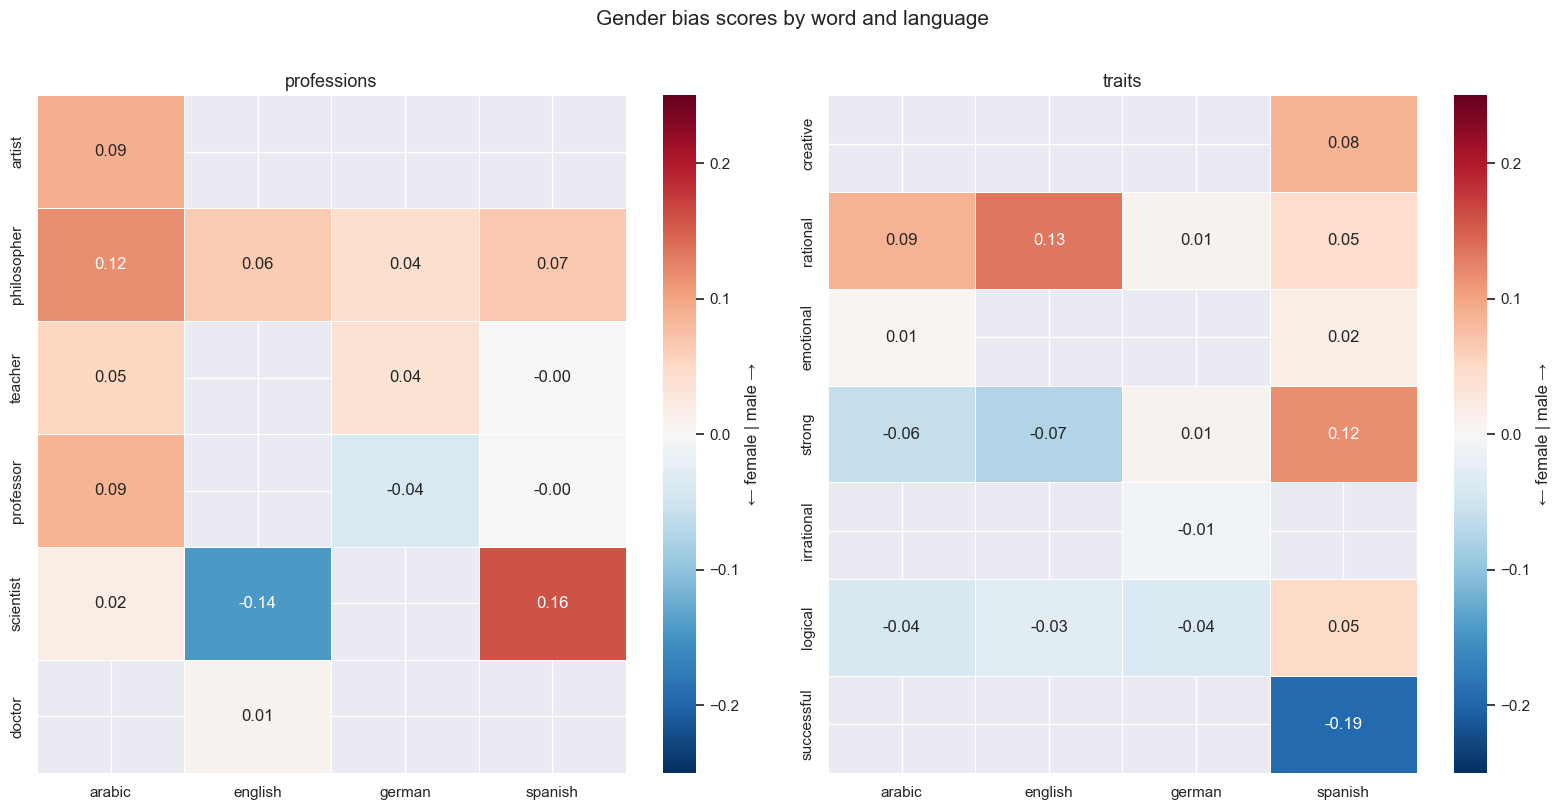

In [31]:
cats = list(TEST_WORDS.keys())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, cat in zip(axes, cats[:2]):
    sub = df[df["category"] == cat]
    pivot = sub.pivot(index="word", columns="language", values="score")
    pivot = pivot.dropna(how="all")
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
    sns.heatmap(
        pivot, ax=ax,
        center=0, cmap="RdBu_r",
        annot=True, fmt=".2f", linewidths=0.5,
        cbar_kws={"label": "← female | male →"},
        vmin=-0.25, vmax=0.25,
    )
    ax.set_title(cat, fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.suptitle("Gender bias scores by word and language", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

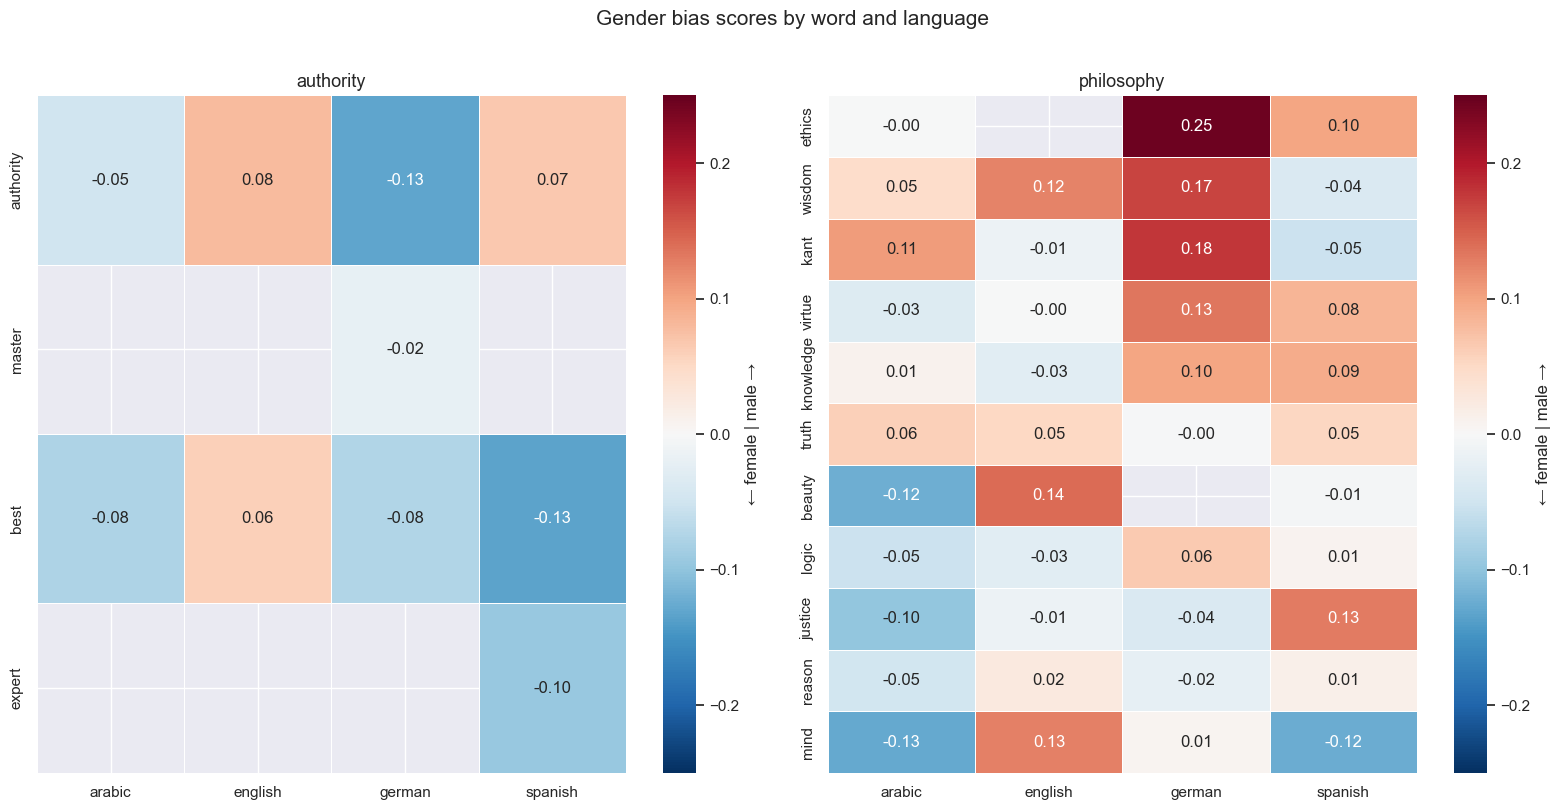

In [32]:
# plot gender bias  scores for authority and philosophy ac
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, cat in zip(axes, cats[2:]):
    sub = df[df["category"] == cat]
    pivot = sub.pivot(index="word", columns="language", values="score")
    pivot = pivot.dropna(how="all")
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
    sns.heatmap(
        pivot, ax=ax,
        center=0, cmap="RdBu_r",
        annot=True, fmt=".2f", linewidths=0.5,
        cbar_kws={"label": "← female | male →"},
        vmin=-0.25, vmax=0.25,
    )
    ax.set_title(cat, fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.suptitle("Gender bias scores by word and language", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

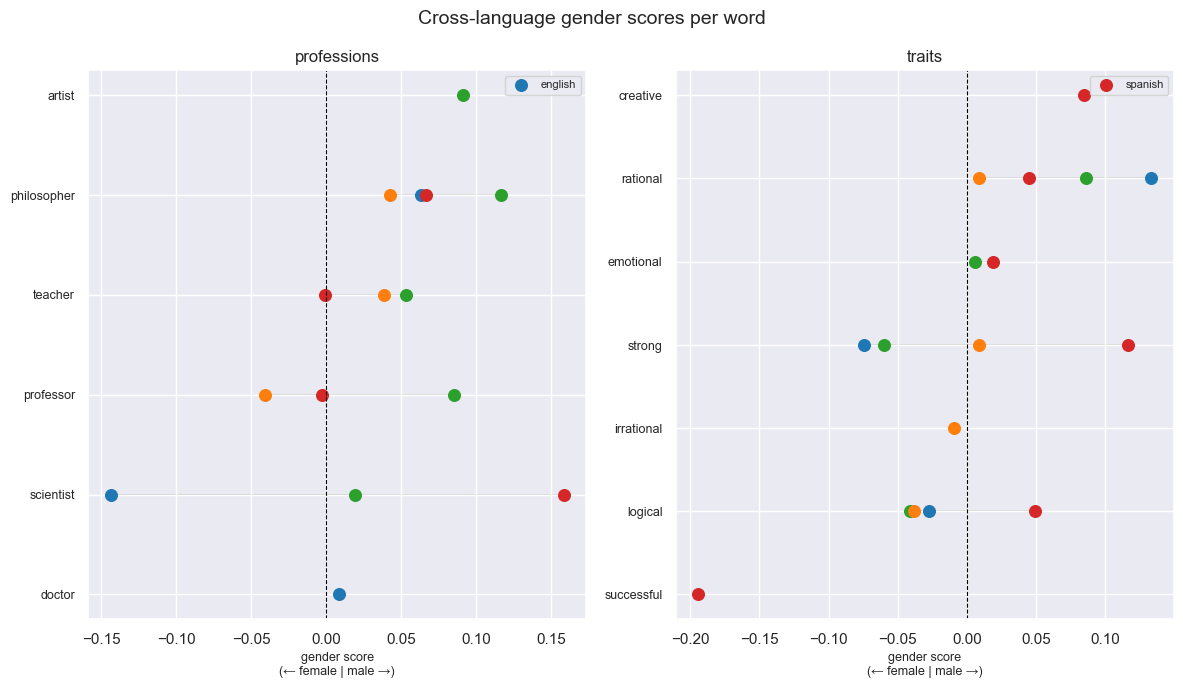

In [33]:
cats = list(TEST_WORDS.keys())
colors = sns.color_palette("tab10", 5)
lang_color = dict(zip(df["language"].unique(), colors))

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
for ax, cat in zip(axes, cats[:2]):
    sub = df[df["category"] == cat]
    pivot = sub.pivot(index="word", columns="language", values="score").dropna(how="all")
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]
    for i, (word, row) in enumerate(pivot.iterrows()):
        valid = row.dropna()
        ax.plot(valid.values, [i] * len(valid), color="lightgray", linewidth=1.2, zorder=0)
        for lang, score in valid.items():
            ax.scatter(score, i, color=lang_color[lang], s=70, zorder=2,
                       label=lang if i == 0 else "")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_xlabel("gender score\n(← female | male →)", fontsize=9)
    ax.set_title(cat, fontsize=12)
    ax.legend(fontsize=8)
plt.suptitle("Cross-language gender scores per word", fontsize=14)
plt.tight_layout()
plt.show()

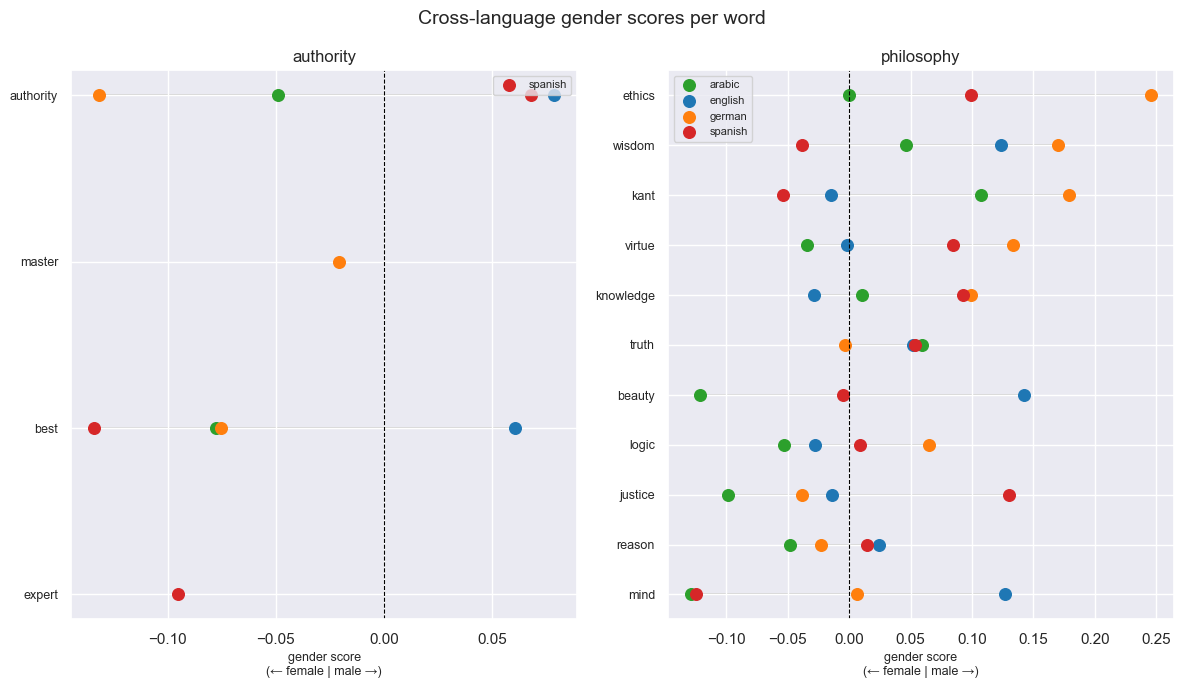

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
for ax, cat in zip(axes, cats[2:]):
    sub = df[df["category"] == cat]
    pivot = sub.pivot(index="word", columns="language", values="score").dropna(how="all")
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]
    for i, (word, row) in enumerate(pivot.iterrows()):
        valid = row.dropna()
        ax.plot(valid.values, [i] * len(valid), color="lightgray", linewidth=1.2, zorder=0)
        for lang, score in valid.items():
            ax.scatter(score, i, color=lang_color[lang], s=70, zorder=2,
                       label=lang if i == 0 else "")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_xlabel("gender score\n(← female | male →)", fontsize=9)
    ax.set_title(cat, fontsize=12)
    ax.legend(fontsize=8)
plt.suptitle("Cross-language gender scores per word", fontsize=14)
plt.tight_layout()
plt.show()

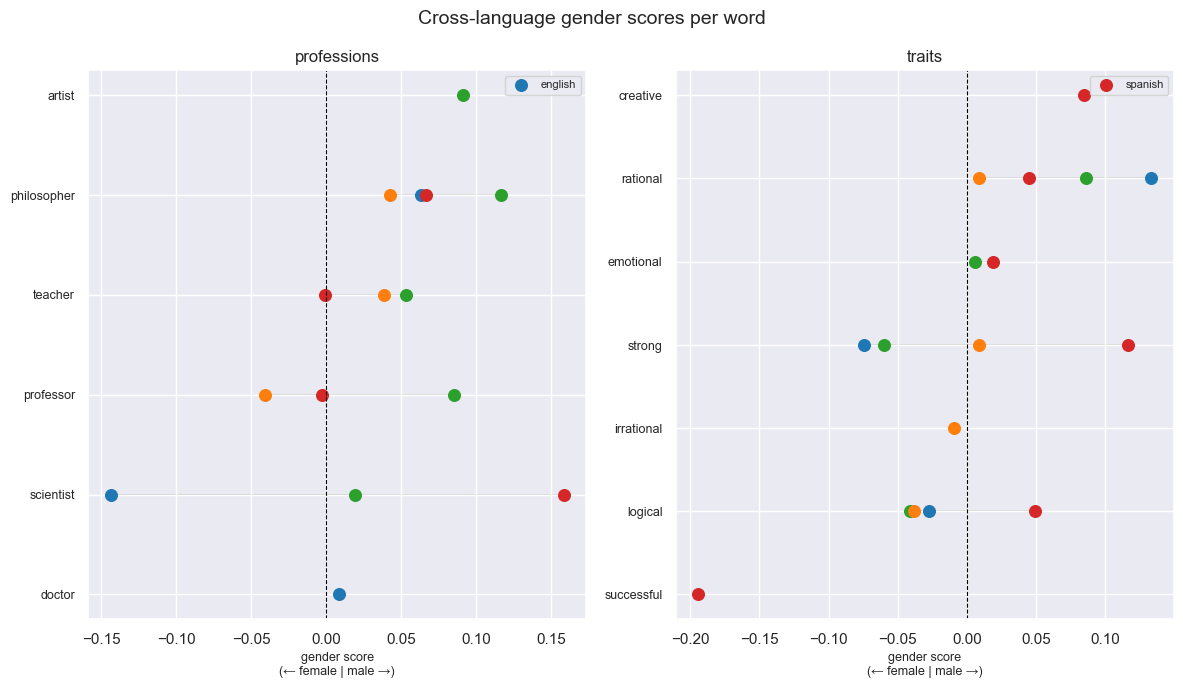

In [35]:
# plot philosopher representation
cats = list(TEST_WORDS.keys())
colors = sns.color_palette("tab10", 5)
lang_color = dict(zip(df["language"].unique(), colors))

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
for ax, cat in zip(axes, cats[:2]):
    sub = df[df["category"] == cat]
    pivot = sub.pivot(index="word", columns="language", values="score").dropna(how="all")
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]
    for i, (word, row) in enumerate(pivot.iterrows()):
        valid = row.dropna()
        ax.plot(valid.values, [i] * len(valid), color="lightgray", linewidth=1.2, zorder=0)
        for lang, score in valid.items():
            ax.scatter(score, i, color=lang_color[lang], s=70, zorder=2,
                       label=lang if i == 0 else "")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_xlabel("gender score\n(← female | male →)", fontsize=9)
    ax.set_title(cat, fontsize=12)
    ax.legend(fontsize=8)
plt.suptitle("Cross-language gender scores per word", fontsize=14)
plt.tight_layout()
plt.show()

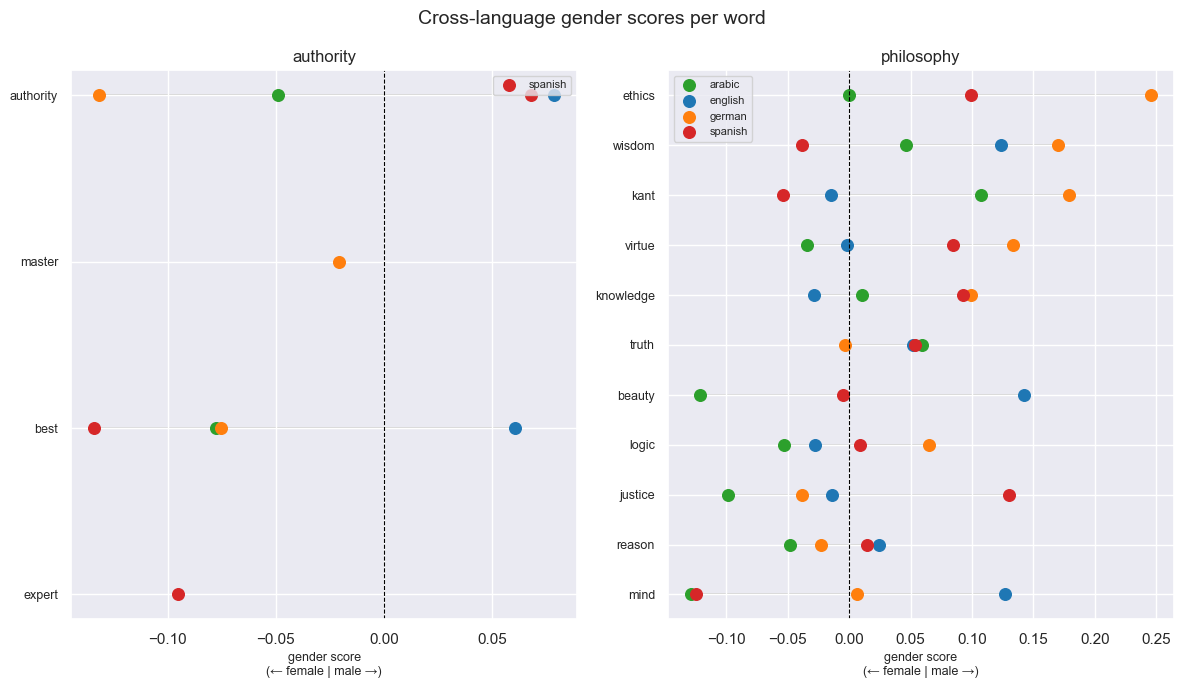

In [36]:
# plot category summary heatmap
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
for ax, cat in zip(axes, cats[2:]):
    sub = df[df["category"] == cat]
    pivot = sub.pivot(index="word", columns="language", values="score").dropna(how="all")
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]
    for i, (word, row) in enumerate(pivot.iterrows()):
        valid = row.dropna()
        ax.plot(valid.values, [i] * len(valid), color="lightgray", linewidth=1.2, zorder=0)
        for lang, score in valid.items():
            ax.scatter(score, i, color=lang_color[lang], s=70, zorder=2,
                       label=lang if i == 0 else "")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_xlabel("gender score\n(← female | male →)", fontsize=9)
    ax.set_title(cat, fontsize=12)
    ax.legend(fontsize=8)
plt.suptitle("Cross-language gender scores per word", fontsize=14)
plt.tight_layout()
plt.show()